In [ ]:
# ── Cell 1: Install dependencies ──────────────────────────────
!pip install -q timm kaggle

In [ ]:
# ── Cell 2: Mount Drive + Kaggle credentials ──────────────────
# Your model checkpoints will be saved to Google Drive
from google.colab import drive, files
drive.mount('/content/drive')

import os

#  paste credentials directly
KAGGLE_USERNAME = ""
KAGGLE_KEY      = ""

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    import json
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
!chmod 600 /root/.kaggle/kaggle.json
print('Kaggle credentials set.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kaggle credentials set.


In [ ]:
# Cell 3: Download datasets
# FER-2013
!kaggle datasets download -d msambare/fer2013 -p /content/fer2013 --unzip -q
print('FER-2013 downloaded.')

# Balanced RAF-DB (75x75)
!kaggle datasets download -d dollyprajapati182/balanced-raf-db-dataset-7575-grayscale -p /content/rafdb --unzip -q
print('RAF-DB downloaded.')

!kaggle datasets download -d mstjebashazida/affectnet -p /content/affectnet --unzip -q
print("AffectNet downloaded.")

# Confirm structure
import os
print('\nFER-2013 contents:', os.listdir('/content/fer2013'))
print('RAF-DB contents:  ', os.listdir('/content/rafdb'))
print('\nAffectNet contents:', os.listdir('/content/affectnet'))


Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
FER-2013 downloaded.
Dataset URL: https://www.kaggle.com/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale
License(s): ODbL-1.0
RAF-DB downloaded.
Dataset URL: https://www.kaggle.com/datasets/mstjebashazida/affectnet
License(s): MIT
AffectNet downloaded.

FER-2013 contents: ['test', 'train']
RAF-DB contents:   ['test', 'train', 'val']

AffectNet contents: ['archive (3)']


In [ ]:
# Cell 4: Inspect folder structure
# Run this to confirm exact subfolder names before building unified set
def print_tree(root, max_depth=2, depth=0):
    if depth > max_depth:
        return
    for item in sorted(os.listdir(root)):
        path = os.path.join(root, item)
        prefix = '  ' * depth
        if os.path.isdir(path):
            count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
            print(f'{prefix}{item}/  ({count} files)')
            print_tree(path, max_depth, depth + 1)
        else:
            if depth == max_depth:
                print(f'{prefix}...')
                return

print('=== FER-2013 ===')
print_tree('/content/fer2013', max_depth=2)
print('\n=== RAF-DB ===')
print_tree('/content/rafdb', max_depth=2)
print('\n=== AffectNet ===')
print_tree('/content/affectnet', max_depth=2)

=== FER-2013 ===
test/  (0 files)
  angry/  (958 files)
    ...
  disgust/  (111 files)
    ...
  fear/  (1024 files)
    ...
  happy/  (1774 files)
    ...
  neutral/  (1233 files)
    ...
  sad/  (1247 files)
    ...
  surprise/  (831 files)
    ...
train/  (0 files)
  angry/  (3995 files)
    ...
  disgust/  (436 files)
    ...
  fear/  (4097 files)
    ...
  happy/  (7215 files)
    ...
  neutral/  (4965 files)
    ...
  sad/  (4830 files)
    ...
  surprise/  (3171 files)
    ...

=== RAF-DB ===
test/  (0 files)
  angry/  (595 files)
    ...
  disgust/  (595 files)
    ...
  fear/  (595 files)
    ...
  happy/  (595 files)
    ...
  neutral/  (595 files)
    ...
  sad/  (595 files)
    ...
  surprise/  (595 files)
    ...
train/  (0 files)
  angry/  (4289 files)
    ...
  disgust/  (4289 files)
    ...
  fear/  (4289 files)
    ...
  happy/  (4289 files)
    ...
  neutral/  (4289 files)
    ...
  sad/  (4289 files)
    ...
  surprise/  (4289 files)
    ...
val/  (0 files)
  angry/

In [ ]:
# Cell 5: Build unified dataset (pooled + re-split)
import shutil, random
from pathlib import Path
from collections import defaultdict

EMOTIONS  = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
OUTDIR    = Path('/content/unified')
SEED      = 42
TRAIN_PCT = 0.75
VAL_PCT   = 0.10
TEST_PCT  = 0.15   # remainder

random.seed(SEED)

AFFECTNET_MAP = {
    'anger':    'angry',
    'disgust':  'disgust',
    'fear':     'fear',
    'happy':    'happy',
    'neutral':  'neutral',
    'sad':      'sad',
    'surprise': 'surprise',
    # contempt → skipped
}

# Sources: (root_dir, split_folders, label_map)
SOURCES = [
    (Path('/content/fer2013'),          ['train', 'test'],          {e: e for e in EMOTIONS}),
    (Path('/content/rafdb'),            ['train', 'val', 'test'],   {e: e for e in EMOTIONS}),
    (Path('/content/affectnet/archive (3)'), ['Train', 'Test'],     AFFECTNET_MAP),
]

# Step 1: Pool all images per emotion
pool = defaultdict(list)   # emotion → [Path, ...]

for root, splits, labelmap in SOURCES:
    for split in splits:
        split_dir = root / split
        if not split_dir.exists():
            print(f'  skip: {split_dir} not found')
            continue
        for folder in split_dir.iterdir():
            if not folder.is_dir():
                continue
            emotion = labelmap.get(folder.name.lower())
            if emotion is None:
                continue
            imgs = [p for p in folder.glob('*')
                    if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
            pool[emotion].extend(imgs)

print('Pool sizes:')
for emo in EMOTIONS:
    print(f'  {emo:<12} {len(pool[emo])}')

# Step 2: Shuffle and split each emotion pool
for split in ['train', 'val', 'test']:
    for emo in EMOTIONS:
        (OUTDIR / split / emo).mkdir(parents=True, exist_ok=True)

print('\nSplitting and copying...')
for emo in EMOTIONS:
    imgs = pool[emo][:]
    random.shuffle(imgs)

    n       = len(imgs)
    n_train = int(n * TRAIN_PCT)
    n_val   = int(n * VAL_PCT)
    # rest goes to test

    splits = {
        'train': imgs[:n_train],
        'val':   imgs[n_train:n_train + n_val],
        'test':  imgs[n_train + n_val:],
    }

    for split, files in splits.items():
        dst = OUTDIR / split / emo
        for i, src in enumerate(files):
            shutil.copy2(src, dst / f'{split}_{emo}_{i:06d}{src.suffix}')

    print(f'  {emo:<12} train={len(splits["train"])}  '
          f'val={len(splits["val"])}  test={len(splits["test"])}')

# Step 3: Summary
print('\nUnified dataset summary:')
for split in ['train', 'val', 'test']:
    total = 0
    print(f'\n  {split}')
    for emo in EMOTIONS:
        n = len(list((OUTDIR / split / emo).glob('*')))
        total += n
        print(f'    {emo:<12} {n}')
    print(f'    {"TOTAL":<12} {total}')

Pool sizes:
  angry        14127
  disgust      8980
  fear         14253
  happy        19989
  neutral      17280
  sad          16708
  surprise     13997

Splitting and copying...
  angry        train=10595  val=1412  test=2120
  disgust      train=6735  val=898  test=1347
  fear         train=10689  val=1425  test=2139
  happy        train=14991  val=1998  test=3000
  neutral      train=12960  val=1728  test=2592
  sad          train=12531  val=1670  test=2507
  surprise     train=10497  val=1399  test=2101

Unified dataset summary:

  train
    angry        10595
    disgust      6735
    fear         10689
    happy        14991
    neutral      12960
    sad          12531
    surprise     10497
    TOTAL        78998

  val
    angry        1412
    disgust      898
    fear         1425
    happy        1998
    neutral      1728
    sad          1670
    surprise     1399
    TOTAL        10530

  test
    angry        2120
    disgust      1347
    fear         2139
    hap

In [ ]:
# Cell 6: DataLoaders
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

IMG_SIZE   = 112
BATCH_SIZE = 32

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(str(OUTDIR / 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(str(OUTDIR / 'val'),   transform=val_tf)
test_ds  = datasets.ImageFolder(str(OUTDIR / 'test'),  transform=val_tf)

# Weighted sampler to handle any remaining class imbalance
class_counts   = [train_ds.targets.count(i) for i in range(len(EMOTIONS))]
sample_weights = [1.0 / class_counts[t] for t in train_ds.targets]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, persistent_workers=True, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, persistent_workers=True, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, persistent_workers=True, pin_memory=True)

# class index → emotion label mapping (save for inference)
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}
print('Class mapping:', train_ds.class_to_idx)
print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')

Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train: 78,998  Val: 10,530  Test: 15,806


In [ ]:
import timm
import torch.nn as nn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

model = timm.create_model(
    'tf_efficientnetv2_s',
    pretrained=True,
    num_classes=0
)

in_features = model.num_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.Hardswish(),
    nn.Dropout(p=0.4),
    nn.Linear(512, len(EMOTIONS))
)

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Using device: cuda
Parameters: 20,836,951


In [ ]:
# Cell 8: Training setup
EPOCHS    = 30
LR        = 3e-4
SAVE_DIR  = '/content/drive/MyDrive/fer_efficientnetv2_s'
os.makedirs(SAVE_DIR, exist_ok=True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'Training for {EPOCHS} epochs, saving to {SAVE_DIR}')

Training for 30 epochs, saving to /content/drive/MyDrive/fer_efficientnetv2_s


In [ ]:
# Cell 9: Training loop

from tqdm import tqdm

best_val_acc = 0.0
history      = {'train_loss': [], 'val_acc': []}
PATIENCE     = 5
no_improve   = 0

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    running_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]")

    for imgs, labels in train_bar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        train_bar.set_postfix(loss=loss.item())

    scheduler.step()

    avg_loss = running_loss / len(train_loader)

    # Validate
    model.eval()
    correct = 0
    total = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]")

    with torch.no_grad():
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            preds = model(imgs).argmax(dim=1)

            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            val_bar.set_postfix(acc=correct / total)

    val_acc = correct / total

    # History
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)

    # Checkpoint + early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_model.pth')
        saved = '✓ saved'
        no_improve = 0
    else:
        no_improve += 1
        saved = f'(no improve {no_improve}/{PATIENCE})'

    print(f"\nEpoch {epoch:02d}/{EPOCHS} | loss={avg_loss:.4f} | val_acc={val_acc:.4f} {saved}\n")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 1/30 [Val]: 100%|██████████| 330/330 [00:17<00:00, 18.86it/s, acc=0.691]



Epoch 01/30 | loss=1.4170 | val_acc=0.6905 ✓ saved



Epoch 2/30 [Val]: 100%|██████████| 330/330 [00:17<00:00, 19.34it/s, acc=0.737]



Epoch 02/30 | loss=1.2510 | val_acc=0.7373 ✓ saved



Epoch 3/30 [Val]: 100%|██████████| 330/330 [00:17<00:00, 18.97it/s, acc=0.766]


...


Epoch 28/30 | loss=0.8121 | val_acc=0.8245 (no improve 3/5)



Epoch 29/30 [Val]: 100%|██████████| 330/330 [00:17<00:00, 18.67it/s, acc=0.825]



Epoch 29/30 | loss=0.8129 | val_acc=0.8250 (no improve 4/5)



Epoch 30/30 [Val]: 100%|██████████| 330/330 [00:17<00:00, 19.08it/s, acc=0.825]


Epoch 30/30 | loss=0.8121 | val_acc=0.8248 (no improve 5/5)


Early stopping triggered at epoch 30

Best val accuracy: 0.8265


In [ ]:
# Cell 10: Test set evaluation
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Load best checkpoint
model.load_state_dict(torch.load(f'{SAVE_DIR}/best_model.pth'))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=[idx_to_class[i] for i in range(len(EMOTIONS))]
))

print('Confusion matrix:')
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

       angry       0.78      0.78      0.78      2120
     disgust       0.89      0.84      0.86      1347
        fear       0.77      0.71      0.74      2139
       happy       0.90      0.92      0.91      3000
     neutral       0.82      0.83      0.83      2592
         sad       0.76      0.78      0.77      2507
    surprise       0.82      0.85      0.84      2101

    accuracy                           0.82     15806
   macro avg       0.82      0.82      0.82     15806
weighted avg       0.82      0.82      0.82     15806

Confusion matrix:
[[1649   61   97   32   78  167   36]
 [  98 1136   23   15    8   41   26]
 [ 118   27 1520   24   57  192  201]
 [  23    8   21 2767  120   28   33]
 [  52    6   36  148 2158  154   38]
 [ 124   28  140   36  175 1958   46]
 [  47   16  136   47   37   39 1779]]


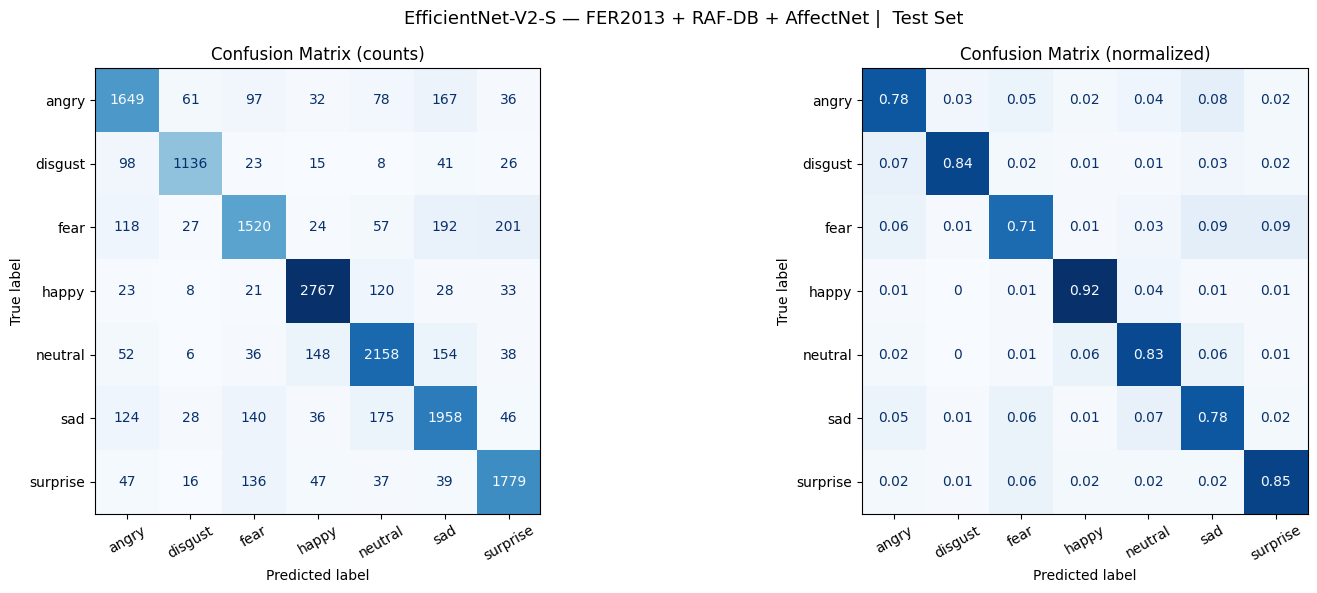

Per-class recall:
  angry        0.778
  disgust      0.843
  fear         0.711
  happy        0.922
  neutral      0.833
  sad          0.781
  surprise     0.847


In [ ]:
# Confusion matrix on test set
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load(f'{SAVE_DIR}/best_model.pth'))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        preds  = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

class_names = [idx_to_class[i] for i in range(len(EMOTIONS))]
cm          = confusion_matrix(all_labels, all_preds)
cm_norm     = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)')
axes[0].tick_params(axis='x', rotation=30)

# Normalized (recall per class)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (normalized)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('EfficientNet-V2-S — FER2013 + RAF-DB + AffectNet |  Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Per-class accuracy summary
print('Per-class recall:')
for i, name in enumerate(class_names):
    print(f'  {name:<12} {cm_norm[i, i]:.3f}')

Evaluated 15806 images, skipped 0

=== DeepFace (old model baseline) — Classification Report ===
              precision    recall  f1-score   support

       angry       0.44      0.47      0.46      2120
     disgust       0.55      0.05      0.09      1347
        fear       0.38      0.35      0.36      2139
       happy       0.60      0.82      0.70      3000
     neutral       0.41      0.60      0.49      2592
         sad       0.45      0.45      0.45      2507
    surprise       0.73      0.35      0.47      2101

    accuracy                           0.49     15806
   macro avg       0.51      0.44      0.43     15806
weighted avg       0.51      0.49      0.46     15806



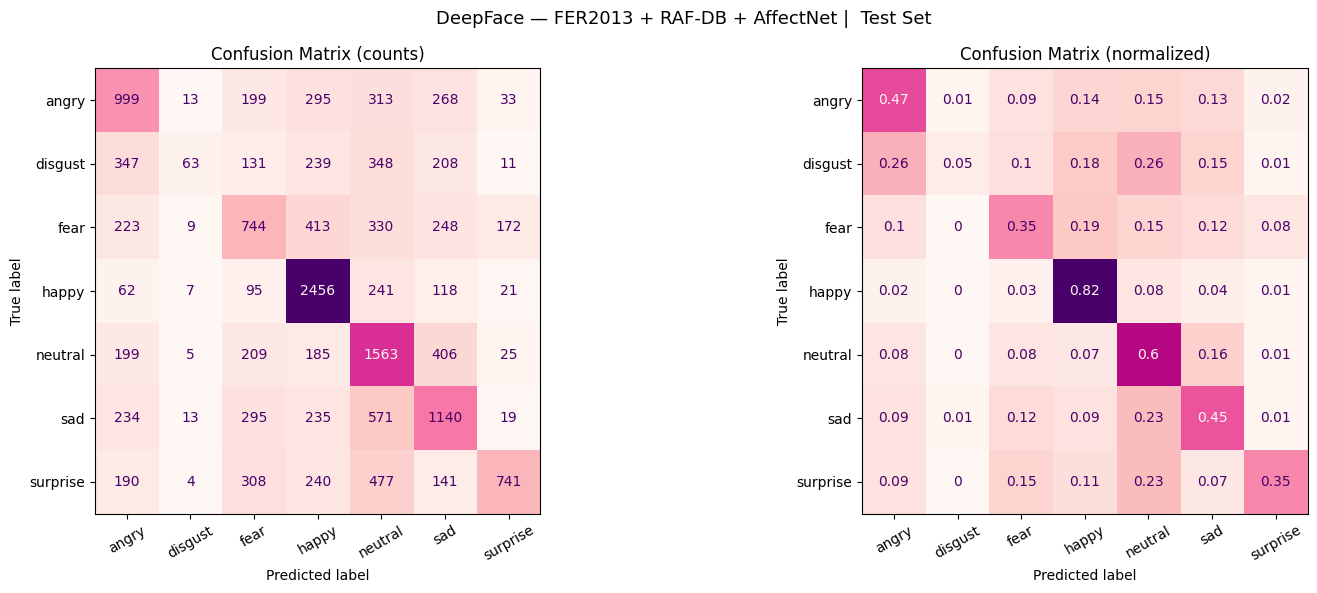

Per-class recall:
  angry        0.471
  disgust      0.047
  fear         0.348
  happy        0.819
  neutral      0.603
  sad          0.455
  surprise     0.353


In [ ]:

# Cell: Benchmark DeepFace

!pip install -q deepface

from deepface import DeepFace
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# DeepFace emotion keys → your label indices
DEEPFACE_EMOTION_MAP = {
    "angry":    0,
    "disgust":  1,
    "fear":     2,
    "happy":    3,
    "neutral":  4,
    "sad":      5,
    "surprise": 6,
}

TESTDIR  = Path("/content/unified/test")
EMOTIONS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

all_preds  = []
all_labels = []
skipped    = 0

for label_idx, emo in enumerate(EMOTIONS):
    emo_dir = TESTDIR / emo
    for img_path in emo_dir.glob("*"):
        img = cv2.imread(str(img_path))
        if img is None:
            skipped += 1
            continue

        try:
            result = DeepFace.analyze(
                img,
                actions=["emotion"],
                enforce_detection=False,  # don't crash if no face found
                silent=True
            )
            pred_emo = result[0]["dominant_emotion"]
        except Exception:
            pred_emo = "neutral"   # safe fallback

        pred_idx = DEEPFACE_EMOTION_MAP.get(pred_emo, 4)
        all_preds.append(pred_idx)
        all_labels.append(label_idx)

print(f"Evaluated {len(all_labels)} images, skipped {skipped}")
print("\n=== DeepFace (old model baseline) — Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

# Confusion matrix plot
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm, display_labels=EMOTIONS).plot(
    ax=axes[0], colorbar=False, cmap='RdPu')
axes[0].set_title('Confusion Matrix (counts)')
axes[0].tick_params(axis='x', rotation=30)

ConfusionMatrixDisplay(cm_norm.round(2), display_labels=EMOTIONS).plot(
    ax=axes[1], colorbar=False, cmap='RdPu')
axes[1].set_title('Confusion Matrix (normalized)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('DeepFace — FER2013 + RAF-DB + AffectNet |  Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix_deepface.png', dpi=120, bbox_inches='tight')
plt.show()

print('Per-class recall:')
for i, name in enumerate(EMOTIONS):
    print(f'  {name:<12} {cm_norm[i, i]:.3f}')

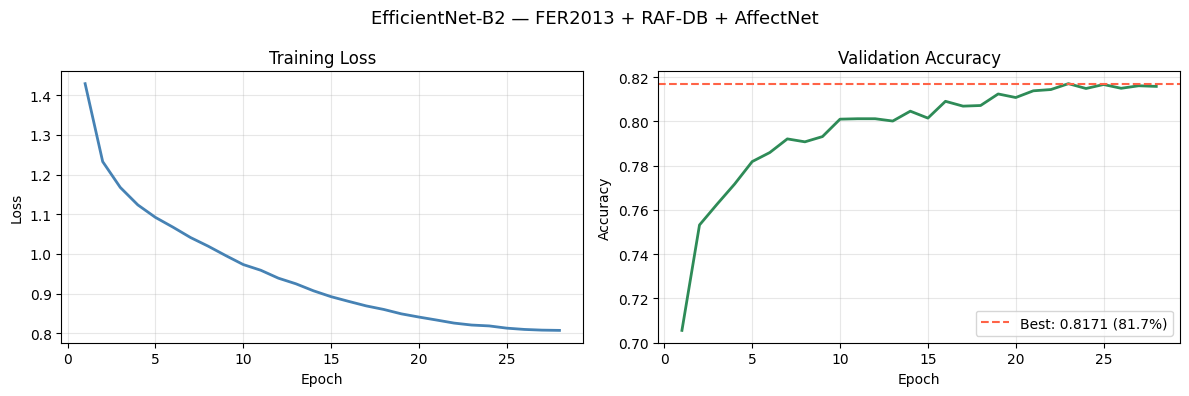

Best val accuracy: 0.8171 (81.7%)


In [ ]:
# Plot training history
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], color='steelblue', linewidth=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['val_acc'], color='seagreen', linewidth=2)
ax2.axhline(best_val_acc, color='tomato', linestyle='--',
            label=f'Best: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('EfficientNet-V2-S — FER2013 + RAF-DB + AffectNet', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Best val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')

In [ ]:
# Cell 12: Export for vision.py
# Saves everything needed to run the model in your project
import json

# Save class index mapping
with open(f'{SAVE_DIR}/class_to_idx.json', 'w') as f:
    json.dump(train_ds.class_to_idx, f, indent=2)

# Save training config for reference
config = {
    'model_name':  'efficientnetv2_s',
    'img_size':    IMG_SIZE,
    'num_classes': len(EMOTIONS),
    'emotions':    EMOTIONS,
    'mean':        MEAN,
    'std':         STD,
    'best_val_acc': round(best_val_acc, 4),
}
with open(f'{SAVE_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved to Google Drive:')
print(f'  {SAVE_DIR}/best_model.pth')
print(f'  {SAVE_DIR}/class_to_idx.json')
print(f'  {SAVE_DIR}/config.json')
print(f'  {SAVE_DIR}/training_curve.png')
print(f'\nBest val accuracy: {best_val_acc:.4f}')

Saved to Google Drive:
  /content/drive/MyDrive/fer_efficientnetv2_s/best_model.pth
  /content/drive/MyDrive/fer_efficientnetv2_s/class_to_idx.json
  /content/drive/MyDrive/fer_efficientnetv2_s/config.json
  /content/drive/MyDrive/fer_efficientnetv2_s/training_curve.png

Best val accuracy: 0.8265
